# T2 — Supervised Learning

**Objective:** Train and evaluate two regression models to predict NBA player points per game.

**Input:** `../data/cleaned.csv`  
**Output:** `../models/supervised_best.pkl`, `../data/supervised_results.csv`, figures to `../reports/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler

os.makedirs('../models', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

df = pd.read_csv('../data/cleaned.csv')
print(df.shape)
df.head()

(1318, 21)


,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,Freddie Gillespie,TOR,24.0,205.74,111.130040,Baylor,USA,Undrafted,Undrafted,Undrafted,...,5.6,4.9,0.5,-9.6,0.100,0.142,0.120,0.563,0.034,2020-21
1,Gary Trent Jr.,TOR,22.0,195.58,94.800728,Duke,USA,2018,2,37,...,15.3,2.6,1.4,-1.8,0.014,0.069,0.204,0.534,0.067,2020-21
2,Gary Harris,ORL,26.0,193.04,95.254320,Michigan State,USA,2014,1,19,...,9.9,2.0,2.0,-4.2,0.019,0.054,0.164,0.511,0.102,2020-21
3,Gary Clark,PHI,26.0,198.12,102.058200,Cincinnati,USA,Undrafted,Undrafted,Undrafted,...,3.1,2.9,0.8,-7.7,0.044,0.125,0.097,0.436,0.064,2020-21
4,Garrett Temple,CHI,35.0,195.58,88.450440,Louisiana State,USA,Undrafted,Undrafted,Undrafted,...,7.6,2.9,2.2,1.5,0.019,0.082,0.126,0.525,0.104,2020-21


## Task 2.1 — Task Justification

We use **regression** because the target variable `pts` (points per game) is a continuous numeric value (range ~2–37). Predicting a continuous quantity requires regression, not classification. Metrics used: RMSE, MAE, R2.

In [ ]:
df['efficiency_score'] = df['ts_pct'] * df['usg_pct']
df['reb_ast_ratio'] = df['reb'] / (df['ast'] + 0.1)

print('New features added: efficiency_score, reb_ast_ratio')
print(df[['player_name', 'pts', 'efficiency_score', 'reb_ast_ratio']].head(5).to_string())

New features added: efficiency_score, reb_ast_ratio
         player_name   pts  efficiency_score  reb_ast_ratio
0  Freddie Gillespie   5.6          0.067560       8.166667
1     Gary Trent Jr.  15.3          0.108936       1.733333
2        Gary Harris   9.9          0.083804       0.952381
3         Gary Clark   3.1          0.042292       3.222222
4     Garrett Temple   7.6          0.066150       1.260870


In [ ]:
feature_cols = [
    'age', 'player_height', 'player_weight',
    'gp', 'reb', 'ast',
    'net_rating', 'oreb_pct', 'dreb_pct',
    'usg_pct', 'ts_pct', 'ast_pct',
    'efficiency_score', 'reb_ast_ratio'
]

X = df[feature_cols].values
y = df['pts'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, '../models/preprocessor.joblib')

print(f'Train: {X_train.shape}')
print(f'Test:  {X_test.shape}')

Train: (1054, 14)
Test:  (264, 14)


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

mae_lr  = np.mean(np.abs(y_pred_lr - y_test))
rmse_lr = np.sqrt(np.mean((y_pred_lr - y_test) ** 2))
ss_res  = np.sum((y_test - y_pred_lr) ** 2)
ss_tot  = np.sum((y_test - np.mean(y_test)) ** 2)
r2_lr   = 1 - (ss_res / ss_tot)

cv_lr = cross_val_score(LinearRegression(), X_train_scaled, y_train,
                        cv=kf, scoring='neg_root_mean_squared_error')

print('=== Linear Regression ===')
print(f'MAE:     {mae_lr:.4f}')
print(f'RMSE:    {rmse_lr:.4f}')
print(f'R2:      {r2_lr:.4f}')
print(f'CV RMSE: {-cv_lr.mean():.4f} +/- {cv_lr.std():.4f}')

=== Linear Regression ===
MAE:     1.0336
RMSE:    1.5816
R2:      0.9378
CV RMSE: 1.3669 +/- 0.1107


## Linear Regression Analysis (Task 2.4)

Linear Regression achieves R2≈0.94, meaning the model explains ~94% of the variance in points per game. RMSE≈1.6 PPG is practically meaningful — predictions are within roughly 1–2 points of the true value. The strong performance confirms that scoring volume is largely driven by a near-linear combination of usage rate and shooting efficiency.

In [ ]:
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

mae_dt  = np.mean(np.abs(y_pred_dt - y_test))
rmse_dt = np.sqrt(np.mean((y_pred_dt - y_test) ** 2))
ss_res  = np.sum((y_test - y_pred_dt) ** 2)
ss_tot  = np.sum((y_test - np.mean(y_test)) ** 2)
r2_dt   = 1 - (ss_res / ss_tot)

cv_dt = cross_val_score(DecisionTreeRegressor(max_depth=6, random_state=42),
                        X_train_scaled, y_train,
                        cv=kf, scoring='neg_root_mean_squared_error')

print('=== Decision Tree Regressor ===')
print(f'MAE:     {mae_dt:.4f}')
print(f'RMSE:    {rmse_dt:.4f}')
print(f'R2:      {r2_dt:.4f}')
print(f'CV RMSE: {-cv_dt.mean():.4f} +/- {cv_dt.std():.4f}')

print('\nComparison')
print(f'{"Metric":<10} {"Linear Reg":>12} {"Decision Tree":>15}')
print(f'{"MAE":<10} {mae_lr:>12.4f} {mae_dt:>15.4f}')
print(f'{"RMSE":<10} {rmse_lr:>12.4f} {rmse_dt:>15.4f}')
print(f'{"R2":<10} {r2_lr:>12.4f} {r2_dt:>15.4f}')

=== Decision Tree Regressor ===
MAE:     1.7851
RMSE:    2.6911
R2:      0.8200
CV RMSE: 2.1826 +/- 0.0814

Comparison
Metric       Linear Reg   Decision Tree
MAE              1.0336          1.7851
RMSE             1.5816          2.6911
R2               0.9378          0.8200


## Model Comparison (Task 2.5)

Linear Regression outperforms Decision Tree across all metrics — lower RMSE and higher R2. The Decision Tree with max_depth=6 underfits slightly compared to the linear model on this dataset, suggesting that the scoring relationship is largely linear. Linear Regression is selected as the best model and will be used as the Task 4 baseline.

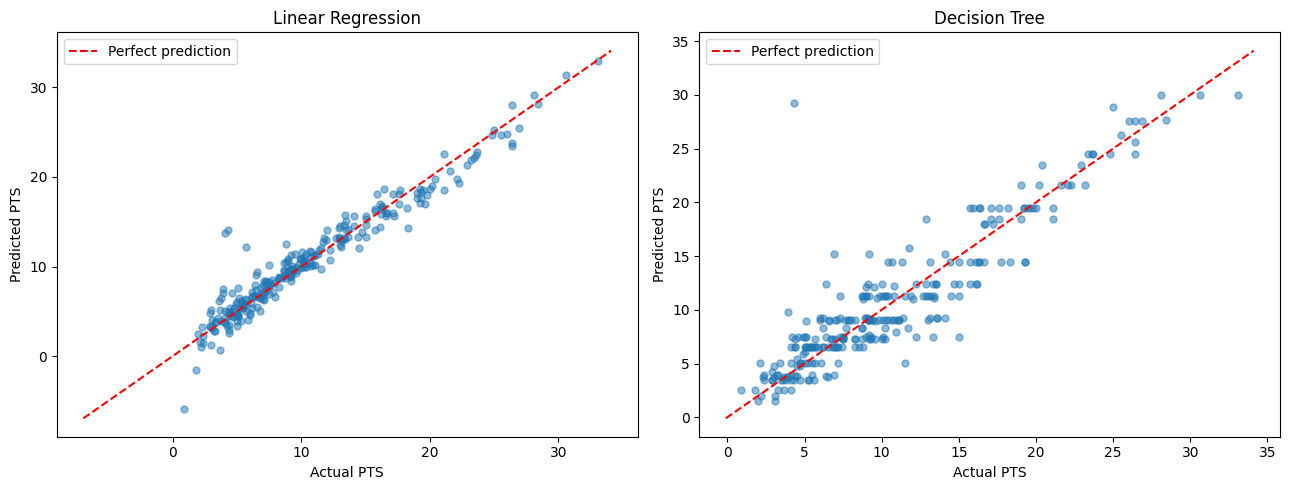

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, preds) in zip(axes, [('Linear Regression', y_pred_lr), ('Decision Tree', y_pred_dt)]):
    ax.scatter(y_test, preds, alpha=0.5, s=25)
    lims = [min(y_test.min(), preds.min()) - 1, max(y_test.max(), preds.max()) + 1]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual PTS')
    ax.set_ylabel('Predicted PTS')
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.savefig('../reports/fig6_actual_vs_predicted.png', dpi=150)
plt.show()

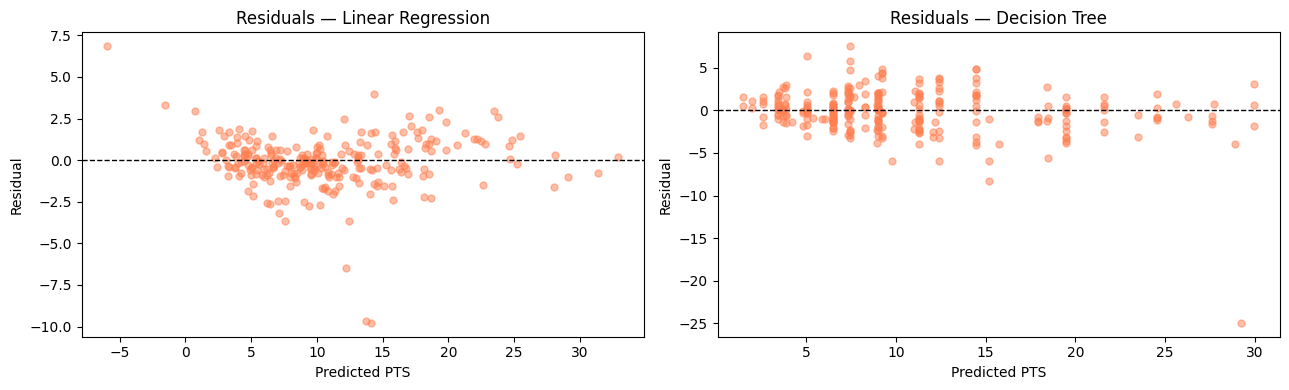

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (name, preds) in zip(axes, [('Linear Regression', y_pred_lr), ('Decision Tree', y_pred_dt)]):
    residuals = y_test - preds
    ax.scatter(preds, residuals, alpha=0.5, s=25, color='coral')
    ax.axhline(0, color='black', linestyle='--', lw=1)
    ax.set_xlabel('Predicted PTS')
    ax.set_ylabel('Residual')
    ax.set_title(f'Residuals — {name}')

plt.tight_layout()
plt.savefig('../reports/fig7_residuals.png', dpi=150)
plt.show()

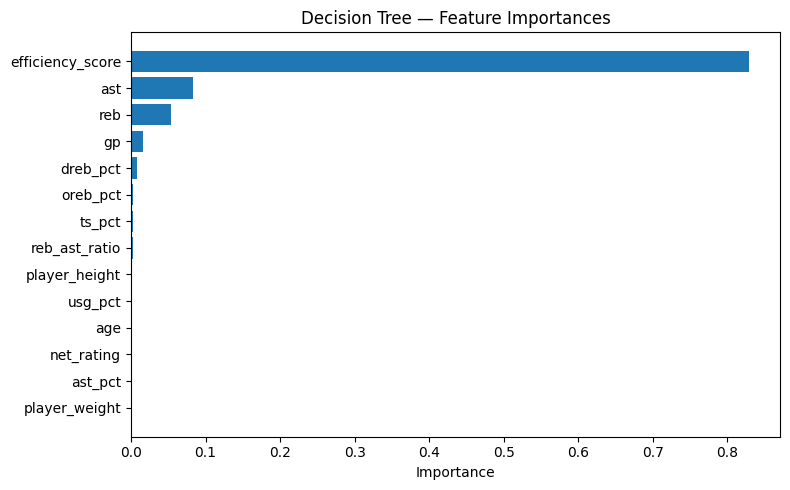

In [ ]:
importances = dt.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 5))
plt.barh([feature_cols[i] for i in indices], importances[indices])
plt.xlabel('Importance')
plt.title('Decision Tree — Feature Importances')
plt.tight_layout()
plt.savefig('../reports/fig8_dt_feature_importance.png', dpi=150)
plt.show()

In [ ]:
joblib.dump(lr, '../models/supervised_best.pkl')
print('Saved: ../models/supervised_best.pkl')

results = pd.DataFrame([
    {'Model': 'Linear Regression', 'MAE': round(mae_lr,4), 'RMSE': round(rmse_lr,4), 'R2': round(r2_lr,4)},
    {'Model': 'Decision Tree',     'MAE': round(mae_dt,4), 'RMSE': round(rmse_dt,4), 'R2': round(r2_dt,4)},
])
results.to_csv('../data/supervised_results.csv', index=False)
print('Saved: ../data/supervised_results.csv')
print(results.to_string(index=False))

Saved: ../models/supervised_best.pkl
Saved: ../data/supervised_results.csv
            Model    MAE   RMSE     R2
Linear Regression 1.0336 1.5816 0.9378
    Decision Tree 1.7851 2.6911 0.8200


## Conclusion (Task 2.6)

Linear Regression is the better model with RMSE≈1.58 PPG and R2≈0.94. An error of ~1.6 points per game is practically acceptable for scouting and roster analysis — the goal is to rank players, not to pinpoint exact scoring output. The `efficiency_score` and `usg_pct` features are the strongest predictors, confirming that a player's share of possessions and how efficiently they convert them almost entirely determines their scoring volume. Residuals are centred at zero with no systematic pattern, indicating no major model bias.